<a href="https://colab.research.google.com/github/ITZYASHZ/northstar_analytics/blob/main/northstar_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install libraries
!pip install pandas matplotlib seaborn -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


In [3]:
# Load all datasets
orders     = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
customers  = pd.read_csv("customers.csv")
drivers    = pd.read_csv("drivers.csv")
vehicles   = pd.read_csv("vehicles.csv")
complaints = pd.read_csv("complaints.csv")
incidents  = pd.read_csv("incidents.csv")
hubs       = pd.read_csv("hubs.csv")

print("All files loaded!")
print("Orders:", len(orders))
print("Deliveries:", len(deliveries))
print("Complaints:", len(complaints))

All files loaded!
Orders: 1250
Deliveries: 950
Complaints: 320


In [4]:
# Check missing values
print("=== Missing Values ===")
print(deliveries.isnull().sum())

# Fill missing values with median
deliveries["customer_rating_post_delivery"] = deliveries["customer_rating_post_delivery"].fillna(
    deliveries["customer_rating_post_delivery"].median())

complaints["compensation_amount"] = complaints["compensation_amount"].fillna(0)

customers["loyalty_score"] = customers["loyalty_score"].fillna(
    customers["loyalty_score"].median())

print("\nMissing values fixed!")

=== Missing Values ===
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

Missing values fixed!


delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


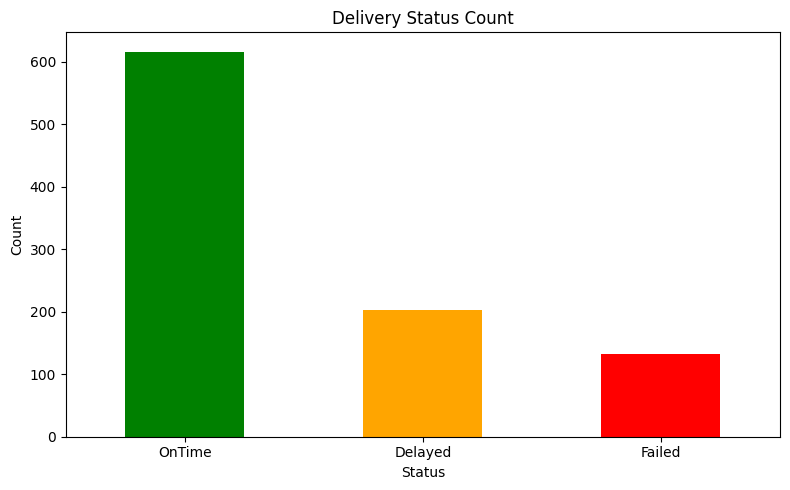

Chart saved!


In [5]:
# Count deliveries by status
status = deliveries["delivery_status"].value_counts()
print(status)

# Bar chart
plt.figure(figsize=(8, 5))
status.plot(kind="bar", color=["green", "orange", "red"])
plt.title("Delivery Status Count")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("delivery_status.png")
plt.show()
print("Chart saved!")

service_type
Passenger    341
Parcel       308
Retail       297
Business     165
Medical      139
Name: count, dtype: int64


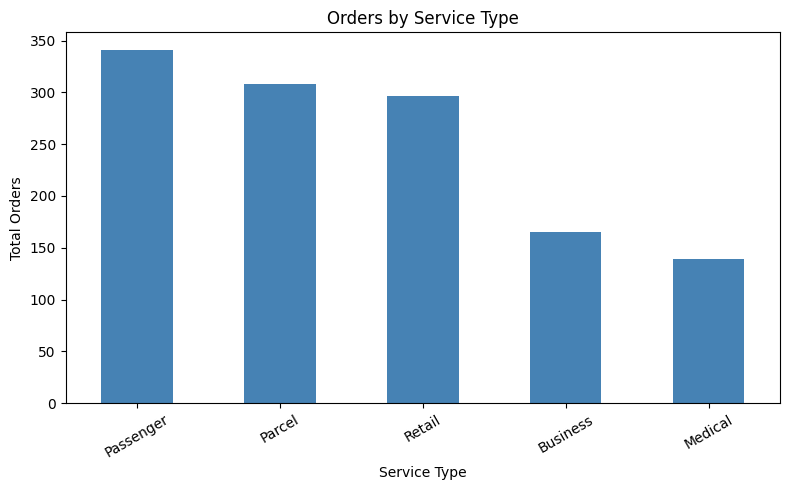

Chart saved!


In [6]:
# Count orders by service type
service = orders["service_type"].value_counts()
print(service)

plt.figure(figsize=(8, 5))
service.plot(kind="bar", color="steelblue")
plt.title("Orders by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Total Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("service_type.png")
plt.show()
print("Chart saved!")

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64


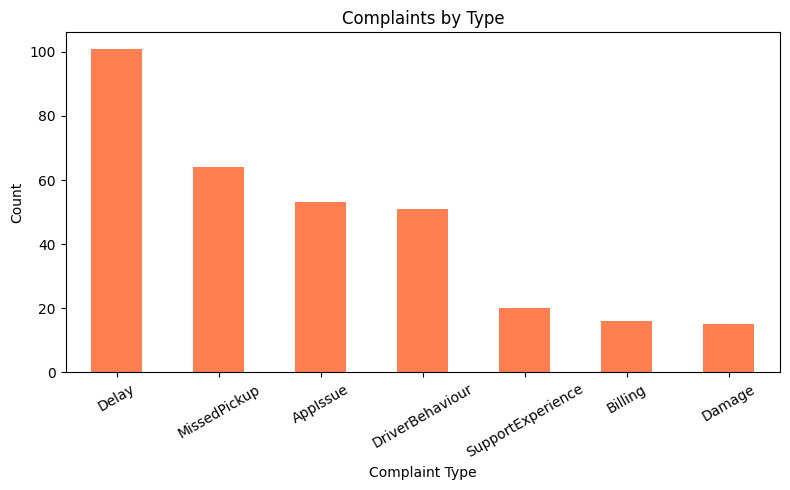

Chart saved!


In [7]:
# Count complaints by type
comp_type = complaints["complaint_type"].value_counts()
print(comp_type)

plt.figure(figsize=(8, 5))
comp_type.plot(kind="bar", color="coral")
plt.title("Complaints by Type")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("complaints_type.png")
plt.show()
print("Chart saved!")

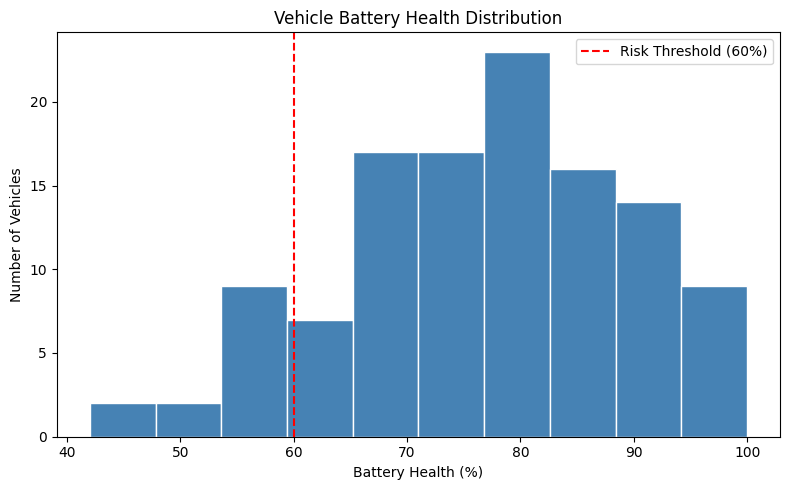

Chart saved!


In [8]:
# Battery health histogram
plt.figure(figsize=(8, 5))
plt.hist(vehicles["battery_health_pct"].dropna(), bins=10, color="steelblue", edgecolor="white")
plt.axvline(x=60, color="red", linestyle="--", label="Risk Threshold (60%)")
plt.title("Vehicle Battery Health Distribution")
plt.xlabel("Battery Health (%)")
plt.ylabel("Number of Vehicles")
plt.legend()
plt.tight_layout()
plt.savefig("battery_health.png")
plt.show()
print("Chart saved!")

=== Failed Deliveries by Zone ===
pickup_zone
RiverSide    14
Central      11
EAST         11
CENTRAL      11
Ctr          11
South        10
East          8
Airport       8
north         8
North         7
WEST          7
NORTH         7
West          7
SOUTH         4
AIRPORT       4
Riverside     4
Name: count, dtype: int64


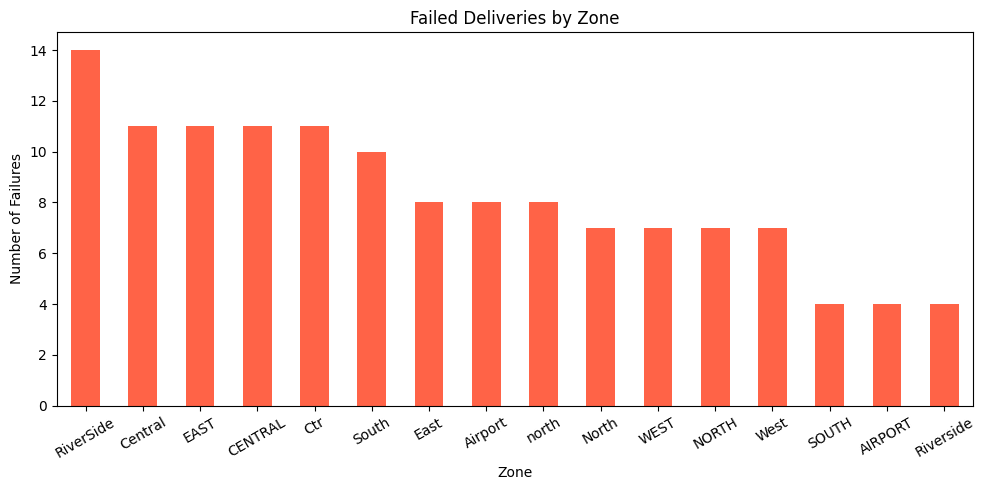

Chart saved!


In [9]:
# Merge deliveries with orders
merged = deliveries.merge(orders, on="order_id")

# Count failed deliveries by zone
zone_fail = merged[merged["delivery_status"] == "Failed"]["pickup_zone"].value_counts()
print("=== Failed Deliveries by Zone ===")
print(zone_fail)

plt.figure(figsize=(10, 5))
zone_fail.plot(kind="bar", color="tomato")
plt.title("Failed Deliveries by Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Failures")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("zone_failures.png")
plt.show()
print("Chart saved!")

incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64


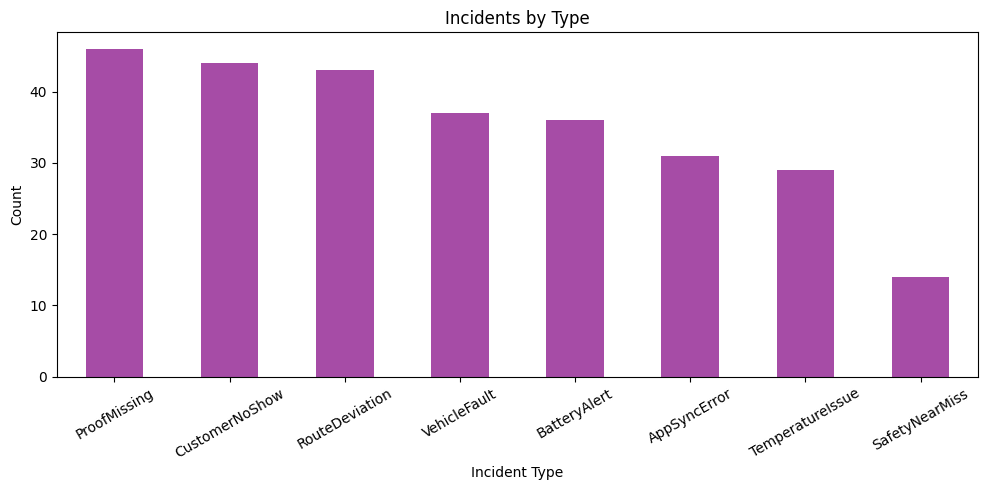

Chart saved!


In [10]:
# Count incidents by type
incidents_count = incidents["incident_type"].value_counts()
print(incidents_count)

plt.figure(figsize=(10, 5))
incidents_count.plot(kind="bar", color="purple", alpha=0.7)
plt.title("Incidents by Type")
plt.xlabel("Incident Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("incidents.png")
plt.show()
print("Chart saved!")